# 250307 Using complex numbers in my code

So last time I got curious about whether I could adjust my code so that complex numbers could be used. So I'm going to try that here. The first change that I'm going to try is simply in the definition of the `costht` function. But from there I may have to specify in the graphs that I only want the real part plotted.

So that throws a warning, but still works. 

One thing that this does that is surprising is when the incident index is larger than the transmitted. The graph is now displaying the real part of whatever the calculation is spitting out, which may or may not be meaningful. In fact I don't think that it is, because there is no transmission beyond the critical angle, yet these graphs are showing that there is.

I'm taking this change out.

# The next thing

I want to find R and T, that is, I know that $R = r^2$ but I don't think that T is that simple. But we need to code those in next and see whether our results are consistent with our sources. 

So first of all, R is the reflectance, and that is the ratio of the reflected power (or flux) to the incident power:

$$R = \frac{I_r A \cos \theta_r}{I_i A \cos \theta_i}$$

but since those angles are equal, that simplifies to 

$$R=\frac{I_r}{I_i}$$

and since $I \propto E^2$ then 

$$R = \frac{E_r^2}{E_i^2} = r^2$$

and so that one is easy.

Although I should note that what I sometimes call the intensity $I$ is probably better written as *irradiance* and that it is the average over time of the Poynting Vector, which is 

$$\vec{S} = c^2 \epsilon_0 \vec{E}\times\vec{B}$$

so that the irradiance becomes

$$I = \langle S_T \rangle = \frac{c \epsilon}{2} E^2$$

Anyways, by the same idea the transmittance, T is the ratio of trasmitted to incident flux so

$$T = \frac{I_t \cos \theta_t}{I_i \cos \theta_i} = \frac{n_t/\mu_t \cos \theta_t}{n_i/\mu_i \cos \theta_i} \left(\frac{E_t}{E_i}\right)^2$$

So that becomes

$$T = \left(\frac{n_t/\mu_t \cos \theta_t}{n_i/\mu_i \cos \theta_i}\right) t^2$$

From here, the parallel (P) and the perpendicular (S) components separate out very naturally and furthermore we have due to the conservation of energy that 

$$R+T=1$$

# Also aesthetically

I switched the colors and dashed markings of this plot to match those found in the Peatross and Ware textbook.

In [1]:
%matplotlib widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def funcPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-2,2))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperp, r$_s$', r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    def plot(ni=1, nt=1.5):
        output1 = func1(ni, nt, thi)
        output2 = func2(ni, nt, thi)
        output3 = func3(ni, nt, thi)
        output4 = func4(ni, nt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1))

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, thi):
    return(arcsin(ni/nt*sin(thi)))

def costht(ni, nt, thi):
    return(np.sqrt(1-(ni/nt*sin(thi))**2))

def rperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    return((ni/mui*cos_thi-nt/mut*cos_tht)/(ni/mui*cos_thi+nt/mut*cos_tht))

def tperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light perpendicular to the 
    plane of incidence and therefore parallel to the interface
    of the material.

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)

    return((2*ni/mui*cos_thi)/(ni/mui*cos_thi+nt/mut*cos_tht))

def rpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    reflection coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((-nt/mut*cos_thi+ni/mui*cos_tht)/(ni/mui*cos_tht+nt/mut*cos_thi))

def tpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((2*ni/mui*cos_thi)/(ni/mui*cos_tht+nt/mut*cos_thi))

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0), FloatSlider(value=1.5, description='n…

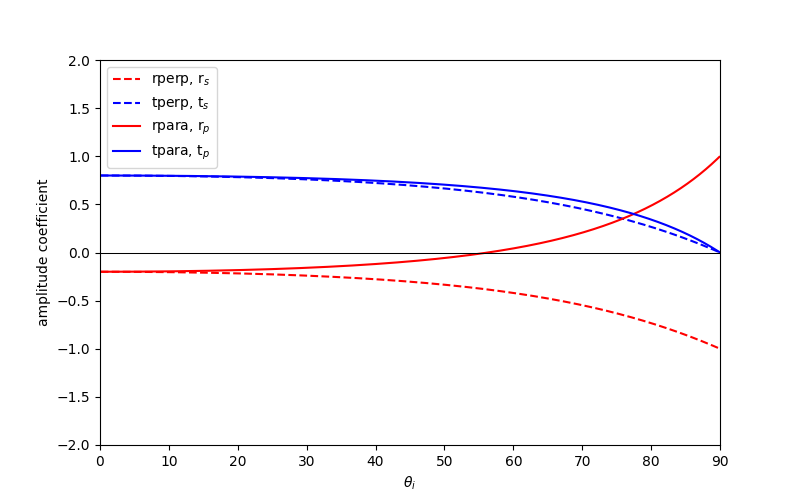

In [3]:
funcPlot(rperp, tperp, rpara, tpara)

# So now for the R and T coefficients

In [4]:
def funcPlot2(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((0,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('Reflectance and Transmittance')
    ax0.legend([r'Rperp, R$_s$', r'Tperp, T$_s$', r'Rpara, R$_p$', r'Tpara, T$_p$'],)
    def plot(ni=1, nt=1.5):
        output1 = func1(ni, nt, thi)
        output2 = func2(ni, nt, thi)
        output3 = func3(ni, nt, thi)
        output4 = func4(ni, nt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1))

def Rperp(ni, nt, thi):
    '''
    reflectance for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    return(rperp(ni, nt, thi)**2)

def Rpara(ni, nt, thi):
    '''
    reflectance for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    return(rpara(ni, nt, thi)**2)

def Tperp(ni, nt, thi):

    cos_tht = costht(ni, nt, thi)
    
    return((nt*cos_tht/ni/cos(thi))*tperp(ni, nt, thi)**2)

def Tpara(ni, nt, thi):

    cos_tht = costht(ni, nt, thi)
    
    return((nt*cos_tht/ni/cos(thi))*tpara(ni, nt, thi)**2)


interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0), FloatSlider(value=1.5, description='n…

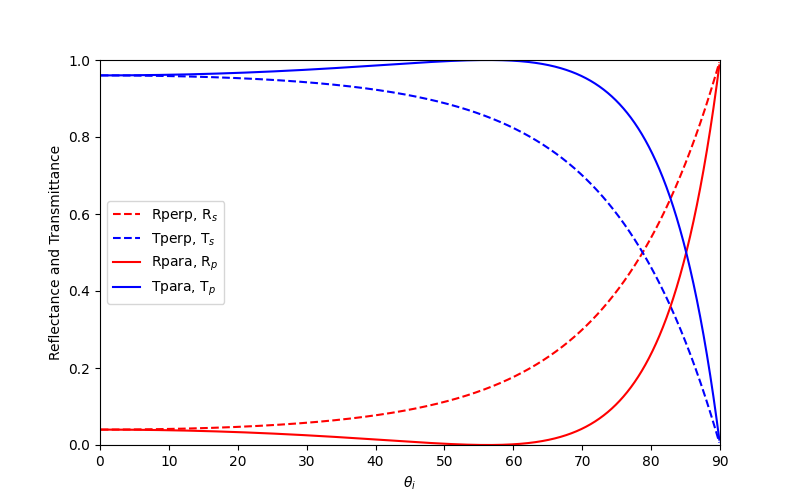

In [5]:
funcPlot2(Rperp, Tperp, Rpara, Tpara)